# 📊 KickProphet: Advanced Exploratory Data Analysis (EDA)

Questo notebook offre un'analisi approfondita del dataset processato, focalizzandosi sulle **metriche chiave per il successo**.
L'obiettivo è rispondere a domande di business come:
- Quali categorie performano meglio?
- Quanto incide la leggibilità della descrizione?
- Quali sono le correlazioni più forti con il successo?

---

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. CARICAMENTO DATI
train_path = '../data/processed/KICKSTARTER_TRAIN.csv'
try:
    df = pd.read_csv(train_path)
    print(f"✅ Dataset caricato: {df.shape}")
except FileNotFoundError:
    print("❌ File non trovato! Esegui 'preprocessing.py'.")

✅ Dataset caricato: (150491, 189)


## 1. Analisi del Target e Categorie
Non ci limitiamo al bilanciamento globale, ma esploriamo il **Tasso di Successo per Categoria**.

In [7]:
# Bilanciamento Globale
target_counts = df['target'].value_counts(normalize=True) * 100
print(f"Tasso di Successo Globale: {target_counts[1]:.2f}%")

# Ricostruzione Categorie (assumendo One-Hot Encoding presente o colonne originali)
# Cerchiamo colonne che iniziano con 'category_main_'
cat_cols = [c for c in df.columns if c.startswith('category_main_')]

if cat_cols:
    # De-One-Hot per visualizzazione
    df_cats = df[cat_cols].idxmax(axis=1).apply(lambda x: x.replace('category_main_', ''))
    df['main_category_label'] = df_cats
    
    # Success Rate per Categoria
    cat_success = df.groupby('main_category_label')['target'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(14, 6))
    sns.barplot(x=cat_success.index, y=cat_success.values, hue=cat_success.index, legend=False, palette="viridis")
    plt.axhline(df['target'].mean(), color='red', linestyle='--', label='Media Globale')
    plt.title("Tasso di Successo per Categoria Principale")
    plt.ylabel("Probabilità di Successo")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

Tasso di Successo Globale: 62.17%


## 2. Analisi Finanziaria & Temporale
Analizziamo l'impatto di `goal_usd` (scalato logaritmicamente) e della durata del progetto.

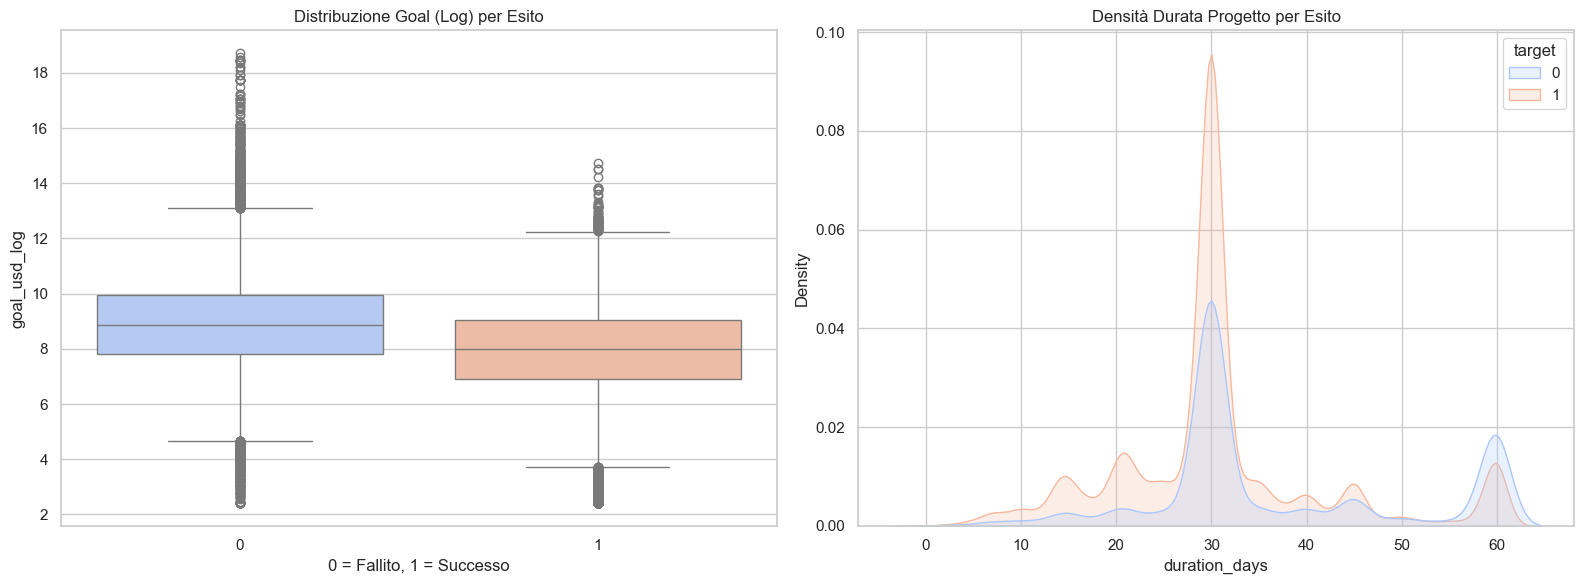

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Goal Log vs Target
if 'goal_usd_log' in df.columns:
    sns.boxplot(x='target', y='goal_usd_log', data=df, ax=axes[0], hue='target', legend=False, palette='coolwarm')
    axes[0].set_title("Distribuzione Goal (Log) per Esito")
    axes[0].set_xlabel("0 = Fallito, 1 = Successo")
    
# Duration vs Target
if 'duration_days' in df.columns:
    sns.kdeplot(data=df, x='duration_days', hue='target', fill=True, ax=axes[1], palette='coolwarm')
    axes[1].set_title("Densità Durata Progetto per Esito")

plt.tight_layout()
plt.show()

## 3. NLP & Readability
I progetti con descrizioni più leggibili hanno più successo? Verifichiamo la distribuzione.

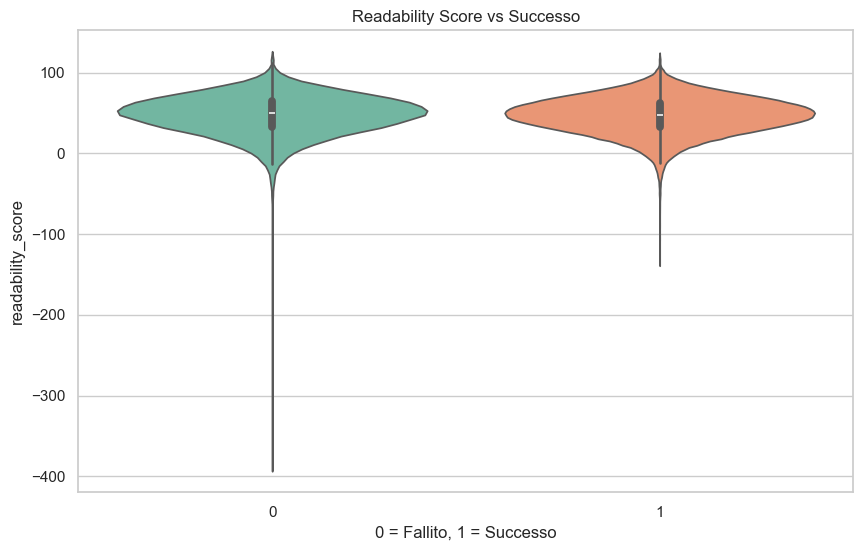

Media Readability Successo: 47.1665930978152
Media Readability Fallimento: 47.89369709386496


In [9]:
if 'readability_score' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='target', y='readability_score', data=df, hue='target', legend=False, palette='Set2')
    plt.title("Readability Score vs Successo")
    plt.xlabel("0 = Fallito, 1 = Successo")
    plt.show()
    
    print("Media Readability Successo:", df[df['target']==1]['readability_score'].mean())
    print("Media Readability Fallimento:", df[df['target']==0]['readability_score'].mean())

## 4. Matrice di Correlazione
Identifichiamo le feature numeriche più correlate, escludendo quelle derivate (come le PCA components) per chiarezza.

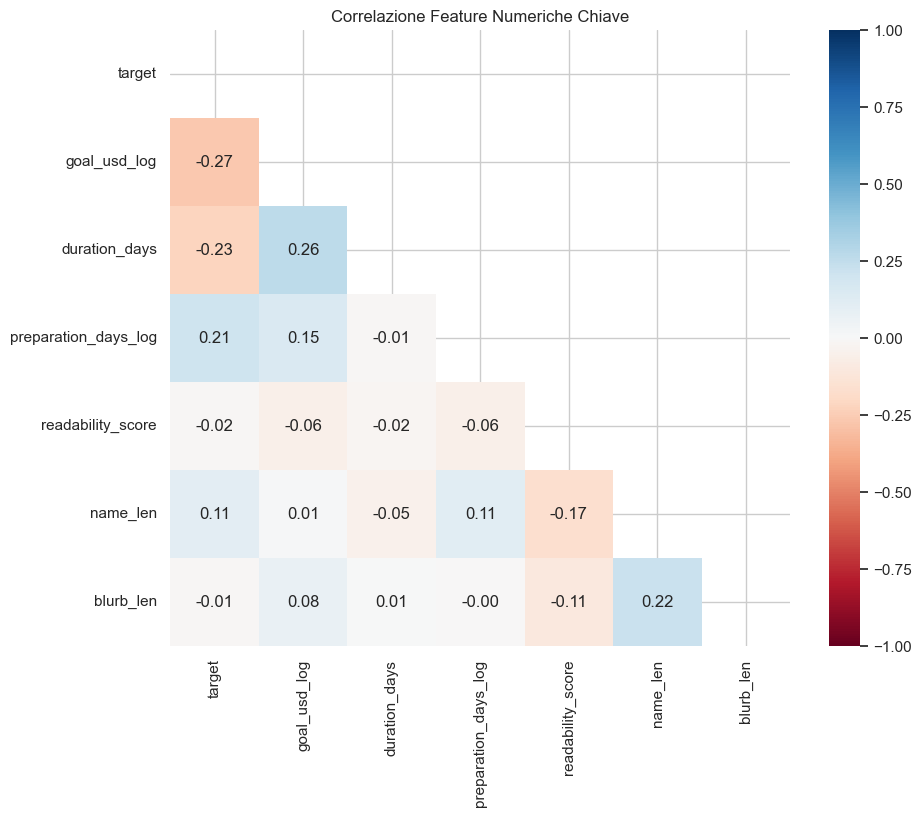

In [10]:
# Selezioniamo feature numeriche chiave (escludendo PCA e OHE massivo)
key_features = [
    'target', 'goal_usd_log', 'duration_days', 'preparation_days_log', 
    'readability_score', 'name_len', 'blurb_len', 'goal_to_cat_diff'
]
cols_to_corr = [c for c in key_features if c in df.columns]

plt.figure(figsize=(10, 8))
corr = df[cols_to_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu', vmin=-1, vmax=1)
plt.title("Correlazione Feature Numeriche Chiave")
plt.show()